# 📌 Submission Guidelines

### ✅ File Naming Rule  
Submit your notebook with the following format:

`StudentID_YourFullName_LABXX.ipynb`

or

`StudentID_YourFullName_LABXX.html`

**Examples (Correct):**
- `21113456_NguyenVanA_LAB01.ipynb`
- `19122233_TranThiB_LAB02.ipynb`

**Examples (Wrong → 0 points):**
- `Lab01.ipynb`
- `YourName.ipynb`
- `20123456.ipynb`
- `Lab01.pdf`

---

### 📌 Grading Policy

- ❌ Wrong filename format, missing submission, or plagiarism (code identical to others) → 0 points

- ⚠️ Submitting a file without results, incomplete work, or only the assignment description → Maximum 4 points

- ✅ Correct filename + Completed results → Graded normally based on assignment quality (accuracy, clarity, and originality)  

### Note:
- AI assistance is allowed, but you must write the code yourself. All submissions will be checked for originality.

---


# **Goal:**

The goal of this lab is to understand the concept of image histograms and learn how to compute and analyze them using OpenCV. By the end of this lab, you will be able to:

Describe what a histogram is and how it represents image pixel intensities.

Understand key concepts: BINS, DIMS, and RANGE.

Visualize and interpret histograms to gain insights into the brightness, contrast, and color distribution of images.

# Background
BINS:

A histogram shows the number of pixels for each intensity value (0–255). Since there are 256 possible pixel values, we typically need 256 bins. Each bin represents an interval of pixel values. For example, bin [0–15] groups all pixels with intensity between 0 and 15.

DIMS:

This indicates the number of parameters for which we collect histogram data. For grayscale or color intensity, dims = 1 because we only measure one thing: pixel intensity.

RANGE:

This is the range of possible pixel values. For 8-bit images, it is [0, 255], representing all possible values from 0 (black) to 255 (white or maximum intensity).

# **Plotting Histograms**

There are two ways for this:

Short Way: use Matplotlib plotting functions

Long Way: use OpenCV drawing functions


# Code sample


In [ ]:
!gdown 1zcyhrWY7-c-hj8q0Se4XFWpDObdVGZqU
!gdown 11bz1c5XTtl8F1gFxIy2Um4CyMRsHpmNx
!gdown 1ret51Duf91ZL8clrEBuo3H3AB5N7YQwV

Downloading...
From: https://drive.google.com/uc?id=1zcyhrWY7-c-hj8q0Se4XFWpDObdVGZqU
To: /content/(2-1).jpeg
100% 133k/133k [00:00<00:00, 15.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=11bz1c5XTtl8F1gFxIy2Um4CyMRsHpmNx
To: /content/(2-2).jpeg
100% 195k/195k [00:00<00:00, 9.50MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ret51Duf91ZL8clrEBuo3H3AB5N7YQwV
To: /content/(2-3).jpeg
100% 128k/128k [00:00<00:00, 20.5MB/s]


In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import os
import gdown
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

In [ ]:
img_1_path = "/content/(2-1).jpeg"
img_2_path = "/content/(2-2).jpeg"
img_3_path = "/content/(2-3).jpeg"

assert os.path.exists(img_1_path), f"File {img_1_path} does not exist"
assert os.path.exists(img_2_path), f"File {img_2_path} does not exist"
assert os.path.exists(img_3_path), f"File {img_3_path} does not exist"

In [ ]:
def imshows(ImageData, LabelData, rows, cols, gridType = False):
  # Convert ImageData and LabelData to List
  ImageArray = list(ImageData)
  LabelArray = list(LabelData)
  if(rows == 1 & cols == 1):
    fig = plt.figure(figsize=(20,20))
  else:
    fig = plt.figure(figsize=(cols*8,rows*5))

  for i in range(1, cols * rows + 1):
      fig.add_subplot(rows, cols, i)
      image = ImageArray[i - 1]
      # If the channel number is less than 3, we display as grayscale image
      # otherwise, we display as color image
      if (len(image.shape) < 3):
          plt.imshow(image, plt.cm.gray)
          plt.grid(gridType)
      else:
          plt.imshow(image)
          plt.grid(gridType)
      plt.title(LabelArray[i - 1])
  plt.show()

def ShowFourImages(IM1, IM2, IM3, IM4):
    imshows([IM1, IM2, IM3, IM4], ["Image 1","Image 2", "Image 3", "Image 4"], 2, 2)
def ShowThreeImages(IM1, IM2, IM3):
    imshows([IM1, IM2, IM3], ["Image 1","Image 2", "Image 3"], 1, 3)
def ShowTwoImages(IM1, IM2):
    imshows([IM1, IM2], ["Image 1","Image 2"], 1, 2)
def ShowOneImage(IM):
    imshows([IM], ["Image"], 1, 1)
def ShowListImages(listImage, row, col):
    listCaption = []
    for i in range(len(listImage)):
        listCaption.append(str(i))
    imshows(listImage,listCaption,row,col)

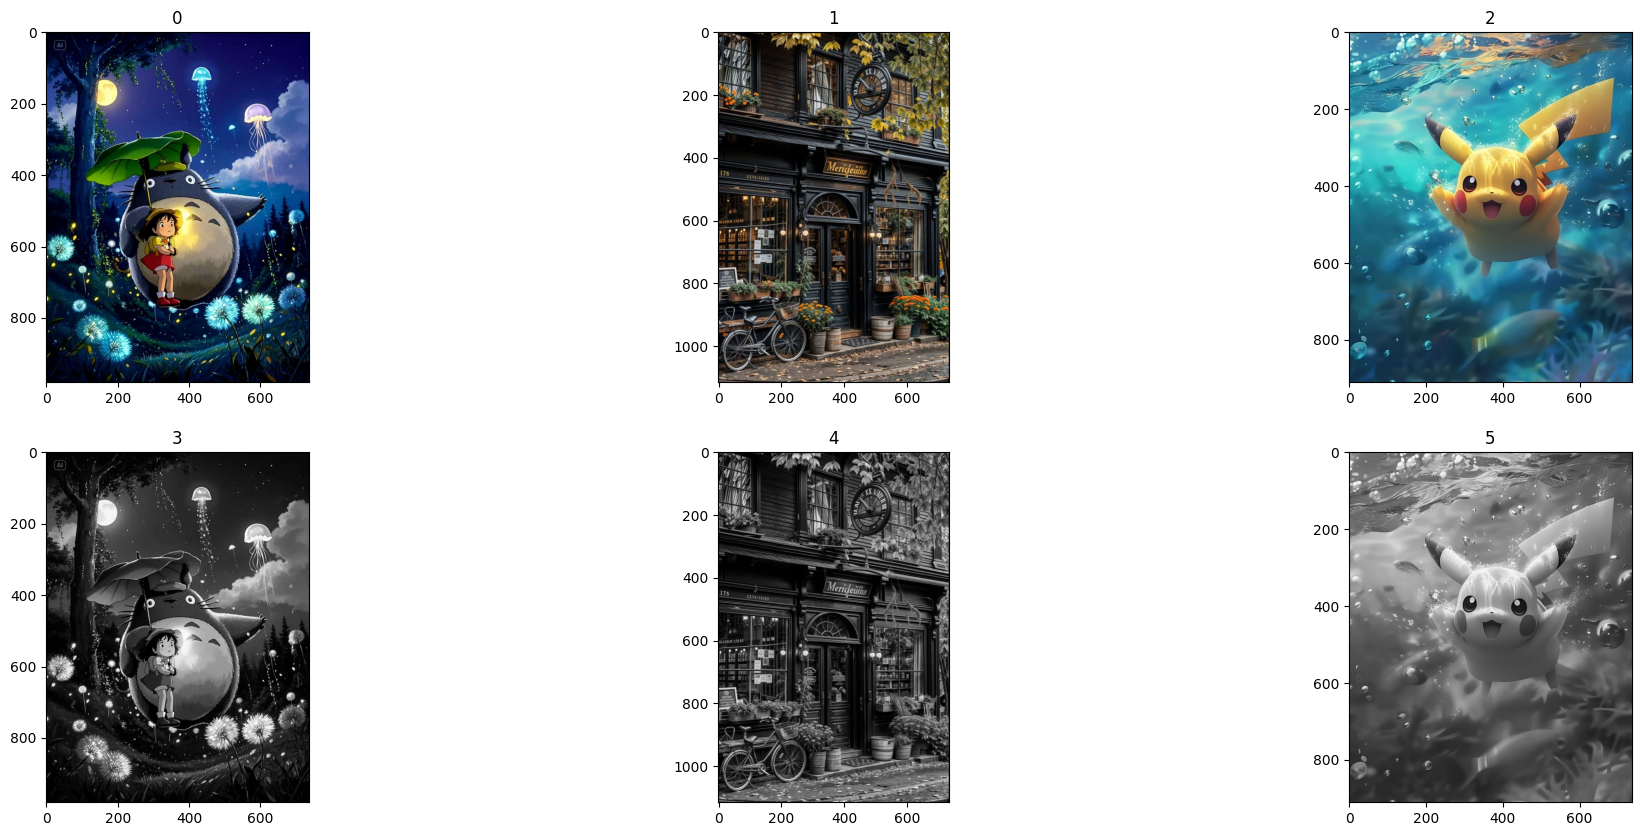

In [ ]:
img_1 = cv.imread(img_1_path)
img_1 = cv.cvtColor(img_1, cv.COLOR_BGR2RGB)
img_2 = cv.imread(img_2_path)
img_2 = cv.cvtColor(img_2, cv.COLOR_BGR2RGB)
img_3_bgr = cv.imread(img_3_path)
img_3_rgb = cv.cvtColor(img_3_bgr, cv.COLOR_BGR2RGB)
img1_GRAYSCALE = cv.imread(img_1_path, cv.IMREAD_GRAYSCALE)
img2_GRAYSCALE = cv.imread(img_2_path, cv.IMREAD_GRAYSCALE)
img3_GRAYSCALE = cv.imread(img_3_path, cv.IMREAD_GRAYSCALE)

ShowListImages([img_1, img_2, img_3_rgb,img1_GRAYSCALE,img2_GRAYSCALE,img3_GRAYSCALE], 2, 3)


## 1. Histogram Calculation





### **Using cv**:

We use the cv.calcHist() function to calculate histograms.
```python
cv.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])
```
#### Parameters:

- images : Source image (grayscale or color). Must be inside square brackets, e.g., [img].

- channels : Index of channel to calculate histogram.

    - For grayscale images: [0]

    - For color images: [0] = Blue, [1] = Green, [2] = Red.

- mask : Region of interest (ROI). If set to None, histogram is calculated for the whole image.

- histSize : Number of bins. Typically [256] for full intensity range.

- ranges : Intensity range. Usually [0, 256].

In [ ]:
img = cv.imread(img_2_path, cv.IMREAD_GRAYSCALE)

assert img_2_path is not None, f"File {img_2_path} could not be read"

hist = cv.calcHist([img], [0], None, [256], [0, 255])

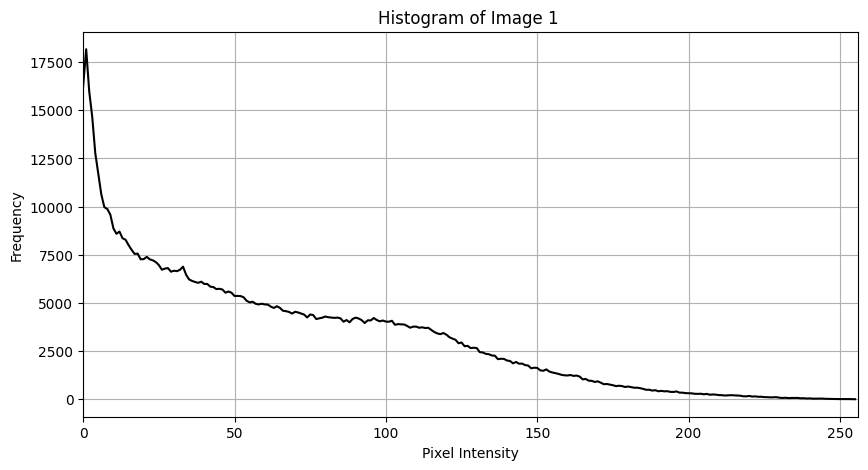

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(hist, color='black')
plt.title('Histogram of Image 1 ')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.grid()
plt.show()


### **Using Matplotlib**

Matplotlib comes with a histogram plotting function : matplotlib.pyplot.hist()

It directly finds the histogram and plot it. You need not use calcHist() or np.histogram() function to find the histogram. See the code below:

/tmp/ipython-input-1776605628.py:2: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img2_GRAYSCALE.ravel(), 256, [0, 255])


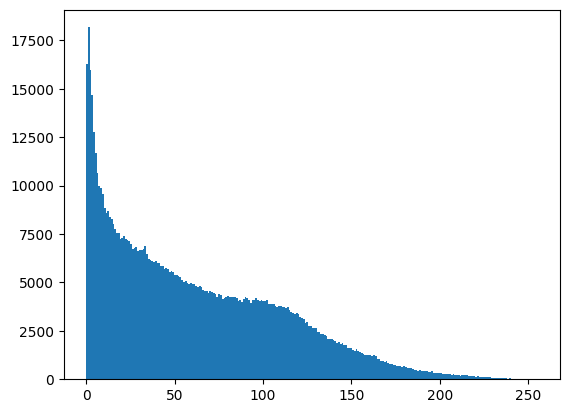

In [ ]:
# Display the histogram of pixel intensities in the grayscale image
plt.hist(img2_GRAYSCALE.ravel(), 256, [0, 255])
plt.show()


Or you can use normal plot of matplotlib, which would be good for BGR plot. For that, you need to find the histogram data first.

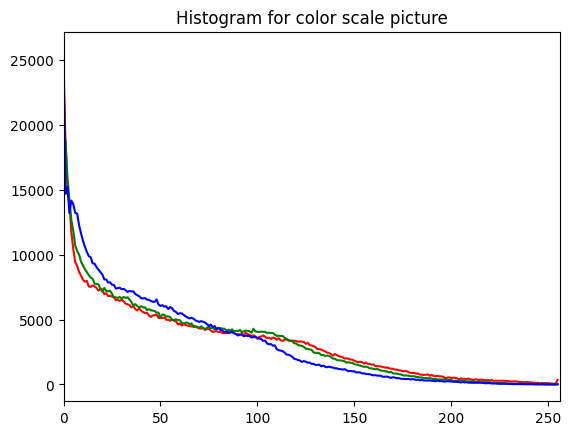

In [ ]:
color = ('r', 'g', 'b')
for channel,col in enumerate(color):
    histr = cv.calcHist([img_2],[channel],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
plt.title('Histogram for color scale picture')
plt.show()

## 2. Histogram Calculation in Numpy

Numpy also provides you a function, `np.histogram()`. So instead of `calcHist()` function, you can try the line below:

```python
hist, bins = np.histogram(img.flatten(), 256, [0, 255])
```
hist is the same as we calculated before. But bins will have 257 elements, because Numpy calculates bins as 0-0.99, 1-1.99, 2-2.99, etc. So the final range would be 255-255.99. To represent that, they also add 256 at the end of bins. But we don’t need that 256. Upto 255 is sufficient.

In [ ]:
hist, bins = np.histogram(img2_GRAYSCALE.flatten(), 256, [0, 255])

### Gamma and log contrast adjustment




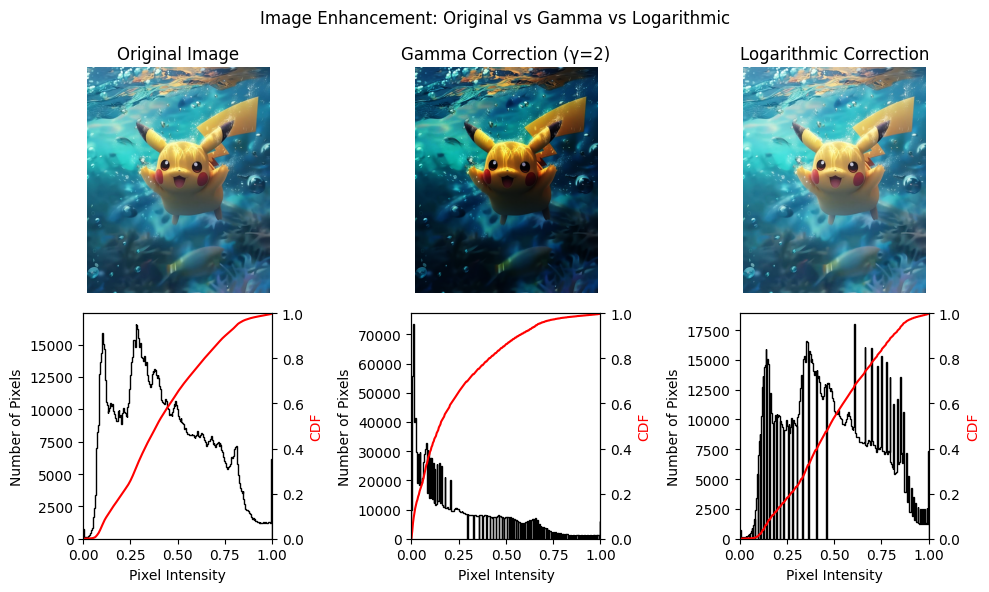

In [ ]:
img = img_as_float(img_3_rgb)   # Convert image to float [0, 1]

# Apply Gamma Correction (γ = 2 → darker)
gamma_corrected = exposure.adjust_gamma(img, 2)

# Apply Logarithmic Correction (gain = 1)
logarithmic_corrected = exposure.adjust_log(img, 1)

# Prepare figure layout
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Image Enhancement: Original vs Gamma vs Logarithmic", fontsize=12)

# List of images and titles
images = [img, gamma_corrected, logarithmic_corrected]
titles = ["Original Image", "Gamma Correction (γ=2)", "Logarithmic Correction"]

# Loop through each image to display + histogram + CDF
for i in range(3):
    image = images[i]

    # --- Display image ---
    axes[0, i].imshow(image, cmap='gray')
    axes[0, i].set_title(titles[i])
    axes[0, i].axis('off')

    # --- Display Histogram ---
    hist, bins = np.histogram(image.ravel(), bins=256, range=(0, 1))
    axes[1, i].hist(image.ravel(), bins=256, color='black', histtype='step', lw=1)
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_xlabel("Pixel Intensity")
    axes[1, i].set_ylabel("Number of Pixels")

    # --- Display CDF on same axis (second y-axis) ---
    cdf = hist.cumsum()
    cdf = cdf / cdf[-1]  # Normalize to [0,1]
    ax_cdf = axes[1, i].twinx()
    ax_cdf.plot(np.linspace(0, 1, len(cdf)), cdf, color='red')
    ax_cdf.set_ylabel("CDF", color='red')
    ax_cdf.set_ylim(0, 1)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


### Histogram Equalization

Consider an image whose pixel values are confined to some specific range of values only. For eg, brighter image will have all pixels confined to high values. But a good image will have pixels from all regions of the image. So you need to stretch this histogram to either ends (as given in below image, from wikipedia) and that is what Histogram Equalization does (in simple words). This normally improves the contrast of the image.



#### Histogram Equalization in Numpy

/tmp/ipython-input-3205756443.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img2_GRAYSCALE.flatten(), 256, [0, 255], color='r', alpha=0.5)  # Plot histogram in red with some transparency


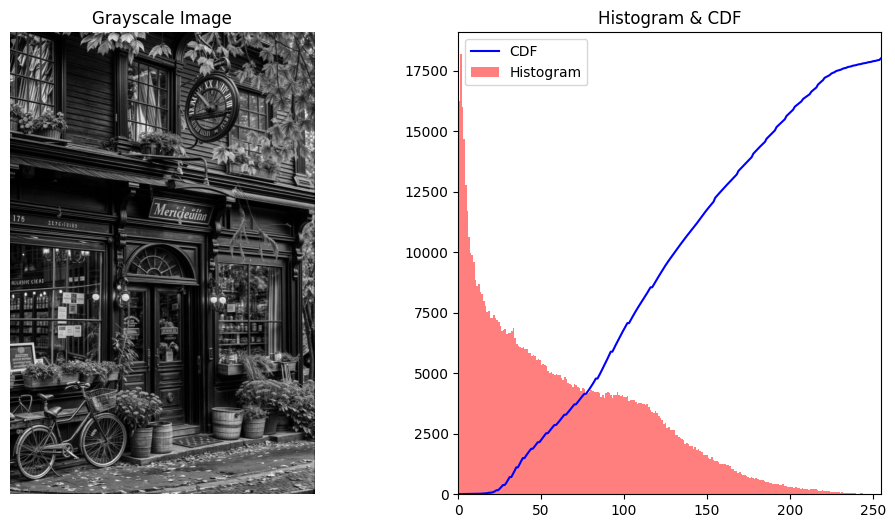

In [ ]:
### Histogram Equalization in Numpy ###

cdf = hist.cumsum()  # Compute cumulative sum to obtain the CDF
cdf_normalized = cdf * float(hist.max()) / cdf.max()  # Normalize CDF for visualization

# Set up the plot figure with a specified size
plt.figure(figsize=(12, 6))

# Plot the grayscale image
plt.subplot(1, 2, 1)
plt.imshow(img2_GRAYSCALE, cmap='gray')  # Display image in grayscale
plt.title("Grayscale Image")  # Set title
plt.axis('off')  # Hide axes

# Plot the histogram and normalized CDF
plt.subplot(1, 2, 2)
plt.plot(cdf_normalized, color='b')  # Plot CDF in blue
plt.hist(img2_GRAYSCALE.flatten(), 256, [0, 255], color='r', alpha=0.5)  # Plot histogram in red with some transparency
plt.xlim([0, 255])  # Set x-axis range for pixel intensities
plt.legend(('CDF', 'Histogram'), loc='upper left')  # Add a legend
plt.title("Histogram & CDF")  # Set title

# Display the plots
plt.show()

Now we find the minimum histogram value (excluding 0) and apply the histogram equalization equation as given in wiki page. But I have used here, the masked array concept array from Numpy. For masked array, all operations are performed on non-masked elements. You can read more about it from Numpy docs on masked arrays.

In [ ]:
hist, bins = np.histogram(img2_GRAYSCALE.flatten(), 256, [0, 256])
cdf = hist.cumsum()
# Mask all zero values in the CDF to avoid issues with division by zero
cdf_m = np.ma.masked_equal(cdf, 0)

# Normalize the CDF values to fit the range [0, 255]
# Subtract the minimum CDF value, multiply by 255, then divide by the range of CDF values (max - min)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())

# Replace masked elements (previously 0 in the original CDF) with 0, and cast to uint8 for image compatibility
cdf = np.ma.filled(cdf_m, 0).astype('uint8')

img2_GRAYSCALE_normalized = cdf[img2_GRAYSCALE]

/tmp/ipython-input-1646225923.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img2_GRAYSCALE_normalized.flatten(), 256, [0, 255], color='r', alpha=0.5)  # Plot histogram in red with some transparency


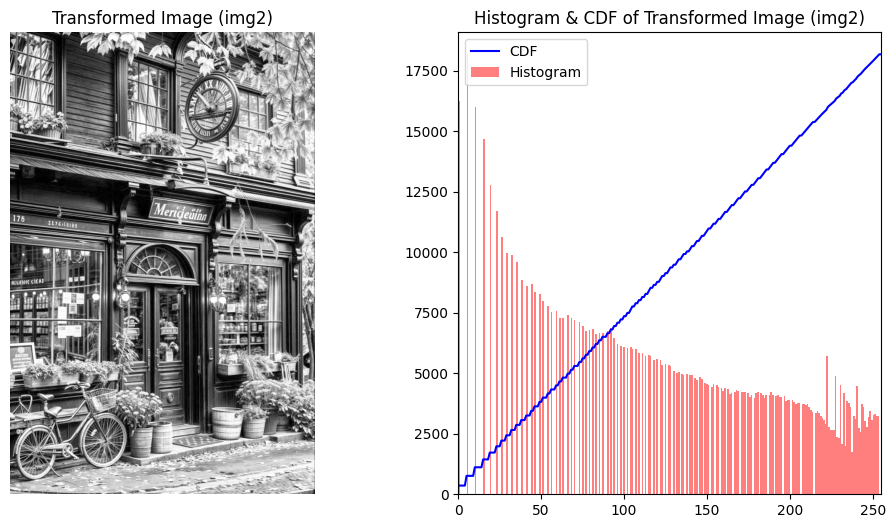

In [ ]:
# Calculate the histogram and cumulative distribution function (CDF) of img2
hist, bins = np.histogram(img2_GRAYSCALE_normalized.flatten(), 256, [0, 255])  # Compute histogram with 256 bins over range [0, 255]
cdf = hist.cumsum()  # Compute cumulative sum to get the CDF
cdf_normalized = cdf * float(hist.max()) / cdf.max()  # Normalize the CDF for visualization

# Set up the plot figure with a specified size
plt.figure(figsize=(12, 6))

# Display img2 as a grayscale image
plt.subplot(1, 2, 1)
plt.imshow(img2_GRAYSCALE_normalized, cmap='gray')  # Display the transformed image in grayscale
plt.title("Transformed Image (img2)")  # Set title
plt.axis('off')  # Hide axes

# Display the histogram and normalized CDF of img2
plt.subplot(1, 2, 2)
plt.plot(cdf_normalized, color='b')  # Plot normalized CDF in blue
plt.hist(img2_GRAYSCALE_normalized.flatten(), 256, [0, 255], color='r', alpha=0.5)  # Plot histogram in red with some transparency
plt.xlim([0, 255])  # Set x-axis range for pixel intensities
plt.legend(('CDF', 'Histogram'), loc='upper left')  # Add a legend for clarity
plt.title("Histogram & CDF of Transformed Image (img2)")  # Set title

# Show the plots
plt.show()


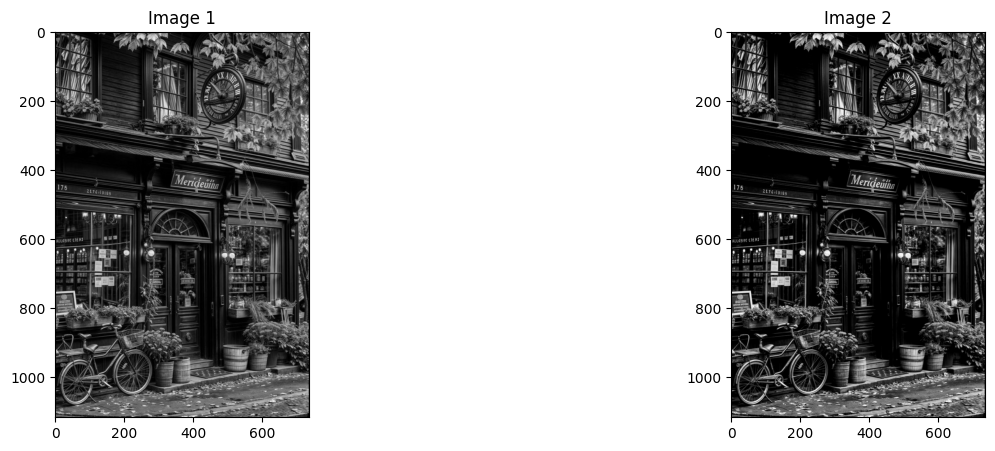

In [ ]:
ShowTwoImages(img2_GRAYSCALE,img2_GRAYSCALE_normalized)

#### Histograms Equalization in OpenCV

OpenCV has a function to do this, cv.equalizeHist(). Its input is just grayscale image and output is our histogram equalized image.

Below is a simple code snippet showing its usage for same image we used

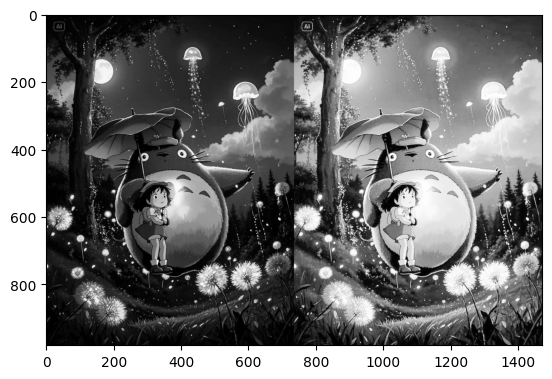

In [ ]:
# Apply histogram equalization to the grayscale image
equ = cv.equalizeHist(img1_GRAYSCALE)

# Stack the original and equalized images side-by-side for comparison
res = np.hstack((img1_GRAYSCALE, equ))  # Combine original (img) and equalized (equ) images horizontally

# Display the stacked image
plt.imshow(res, cmap="gray")  # Show 'res' as a grayscale image
plt.show()

### CLAHE (Contrast Limited Adaptive Histogram Equalization)

The first histogram equalization we just saw, considers the global contrast of the image. In many cases, it is not a good idea. For example, below image shows an input image and its result after global histogram equalization.

It is true that the background contrast has improved after histogram equalization. But compare the face of statue in both images. We lost most of the information there due to over-brightness. It is because its histogram is not confined to a particular region as we saw in previous cases (Try to plot histogram of input image, you will get more intuition).

The cv.createCLAHE() function in OpenCV creates a CLAHE object for applying contrast-limited adaptive histogram equalization. Unlike global histogram equalization, it enhances local contrast by dividing the image into small tiles and limiting the amplification of noise. The parameters clipLimit controls contrast and tileGridSize defines the number of tiles.

```python
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
```

- clipLimit = 2.0

  - Threshold for contrast limiting.

  - Higher values → more contrast, but may introduce noise.

  - Lower values → less enhancement, smoother result.

- tileGridSize = (8, 8)

  - The image is divided into 8×8 tiles.

  - Histogram equalization is applied to each tile individually.

  - Smaller grids → more local enhancement. Larger grids → closer to global equalization.

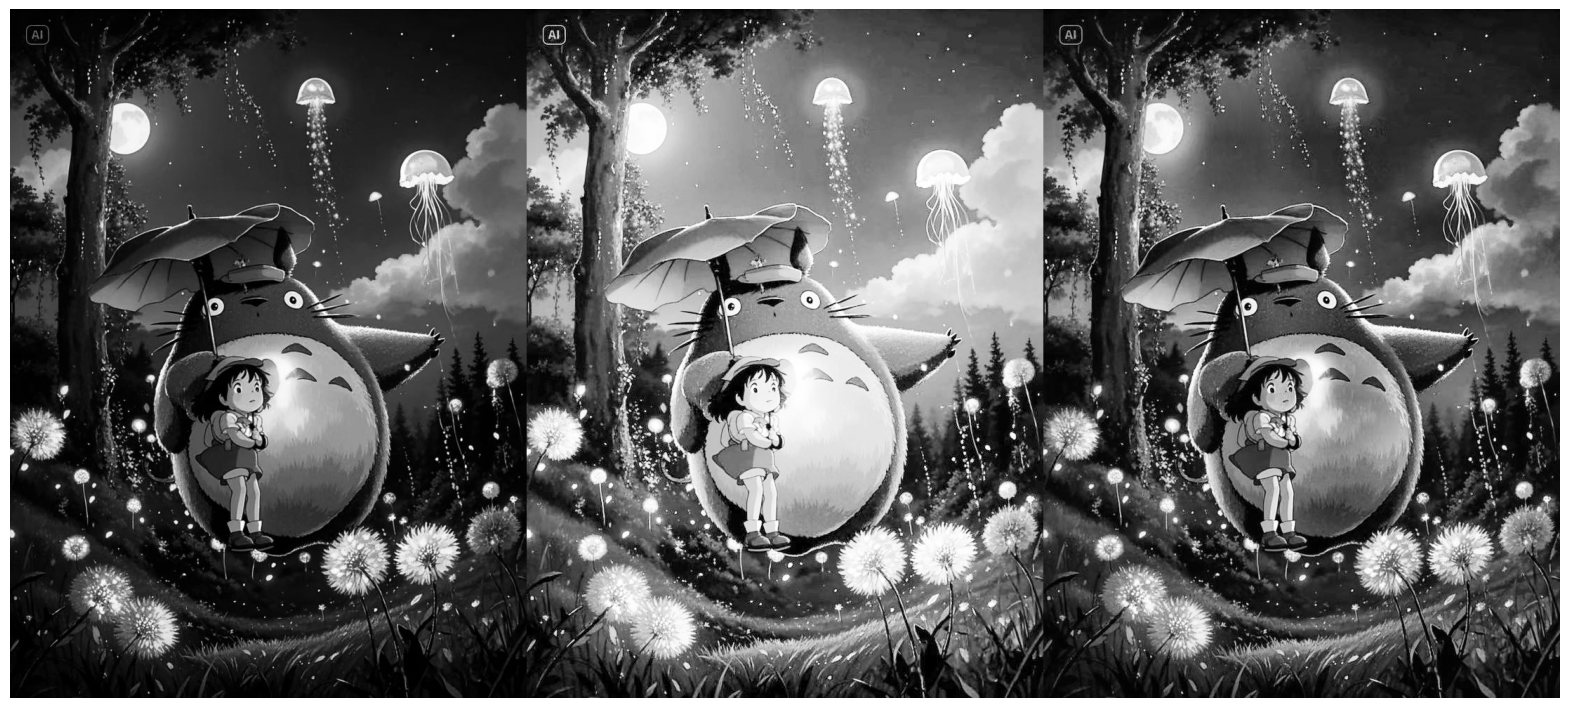

In [ ]:
# Create a CLAHE (Contrast Limited Adaptive Histogram Equalization) object
# clipLimit: sets the threshold for contrast limiting
# tileGridSize: defines the number of tiles in the grid (here, an 8x8 grid)
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply the CLAHE to the grayscale image
cl1 = clahe.apply(img1_GRAYSCALE)

# Stack the original image, the equalized image, and the CLAHE result side-by-side
res = np.hstack((img1_GRAYSCALE, equ, cl1))  # Combine 'img', 'equ', and 'cl1' horizontally

# Set the figure size for the display
plt.figure(figsize=(20, 20))  # Create a figure with a width and height of 20 inches

# Display the stacked image with a grayscale color map
plt.imshow(res, cmap="gray")  # Show the combined image in grayscale
plt.axis('off')  # Turn off axis ticks and labels for a cleaner look

# Render the image
plt.show()  # Display the figure with the stacked images

## **Application of Mask**

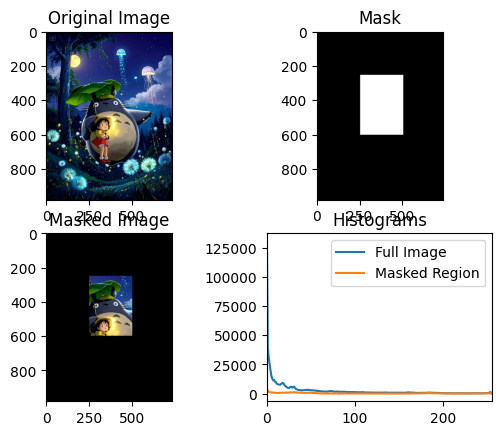

In [ ]:
# Create a mask with the same dimensions as the image, initialized to 0 (black)
mask = np.zeros(img_1.shape[:2], np.uint8)

# Define a rectangular region in the mask (from row 100 to 400, and column 300 to 650) and set it to 255 (white)
mask[250:600, 250:500] = 255

# Apply the mask to the image using a bitwise AND operation
masked_img = cv.bitwise_and(img_1, img_1, mask=mask)

# Calculate histogram of the full image (no mask) and the masked region only
hist_full = cv.calcHist([img_1], [0], None, [256], [0, 255])  # Histogram of full image
hist_mask = cv.calcHist([img_1], [0], mask, [256], [0, 255])  # Histogram of masked region only

# Set up subplots to display the images and histograms
plt.subplot(221), plt.imshow(img_1, 'gray')  # Original image
plt.title("Original Image")

plt.subplot(222), plt.imshow(mask, 'gray')  # Display the mask
plt.title("Mask")

plt.subplot(223), plt.imshow(masked_img, 'gray')  # Display the masked image
plt.title("Masked Image")

# Display histograms: full image histogram and masked region histogram
plt.subplot(224), plt.plot(hist_full, label='Full Image'), plt.plot(hist_mask, label='Masked Region')
plt.xlim([0, 256])  # Set x-axis range for pixel intensities
plt.legend()  # Add a legend to distinguish between histograms
plt.title("Histograms")

# Display all subplots
plt.show()


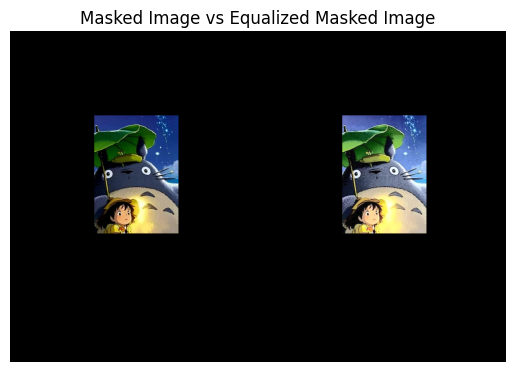

In [ ]:
# convert RGB to YCrCb space
ycrcb = cv.cvtColor(masked_img, cv.COLOR_RGB2YCrCb)

# sparse the channel
y, cr, cb = cv.split(ycrcb)

# equalize the histogram
y_eq = cv.equalizeHist(y)

# combine all of channel
ycrcb_eq = cv.merge([y_eq, cr, cb])

# inverse to RGB
img_eq = cv.cvtColor(ycrcb_eq, cv.COLOR_YCrCb2RGB)


# Stack the original masked image and the equalized image side-by-side for comparison
res = np.hstack((masked_img, img_eq))  # Combine 'masked_img' and 'equ' horizontally

# Save the resulting stacked image as 'imgKarlMax_Maskres.png'
cv.imwrite('imgKarlMax_Maskres.png', res)

# Display the stacked image
plt.imshow(res, cmap="gray")  # Show the combined image in grayscale
plt.title("Masked Image vs Equalized Masked Image")  # Set title for clarity
plt.axis('off')  # Hide axes for a cleaner display

# Render the image
plt.show()


In [ ]:
def max_rgb_filter(image):
    # split the image into its BGR components
    (R, G, B) = cv.split(image)
    # find the maximum pixel intensity values for each
    # (x, y)-coordinate,, then set all pixel values less
    # than M to zero
    M = np.maximum(np.maximum(R, G), B)
    R[R < M] = 0
    G[G < M] = 0
    B[B < M] = 0
    # merge the channels back together and return the image
    return cv.merge([R, G, B])

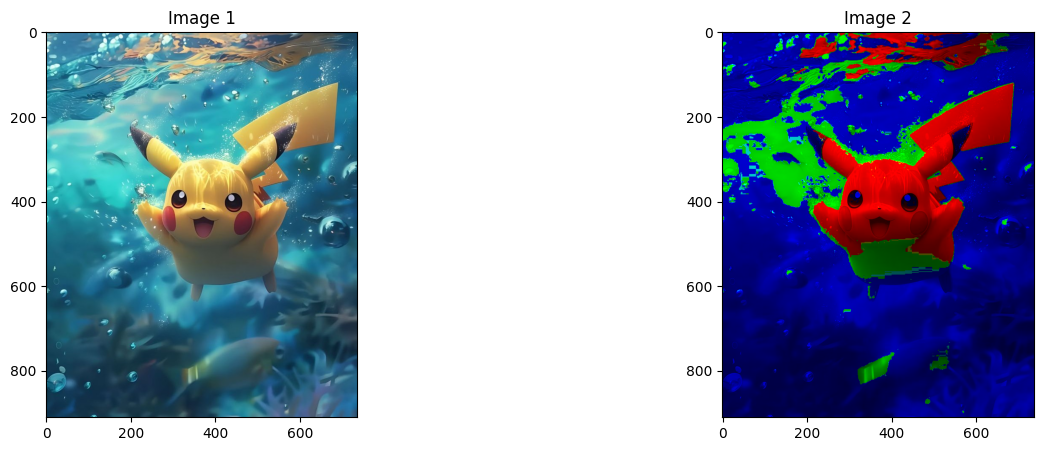

In [ ]:
image_color_rgbmax = max_rgb_filter(img_3_rgb)
ShowTwoImages(img_3_rgb, image_color_rgbmax)

In [ ]:
def SegmentColorImageByMask(IM, Mask):
    Mask = Mask.astype(np.uint8)
    result = cv.bitwise_and(IM, IM, mask = Mask)
    return result

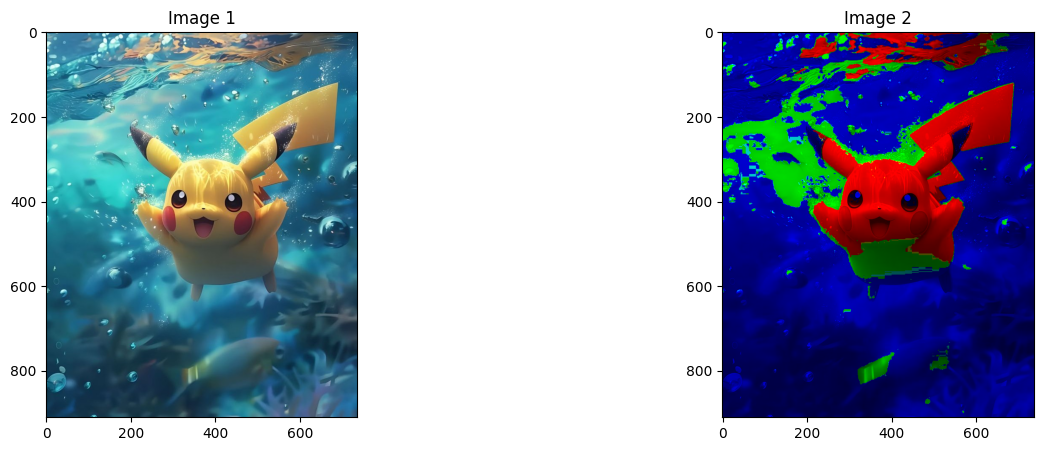

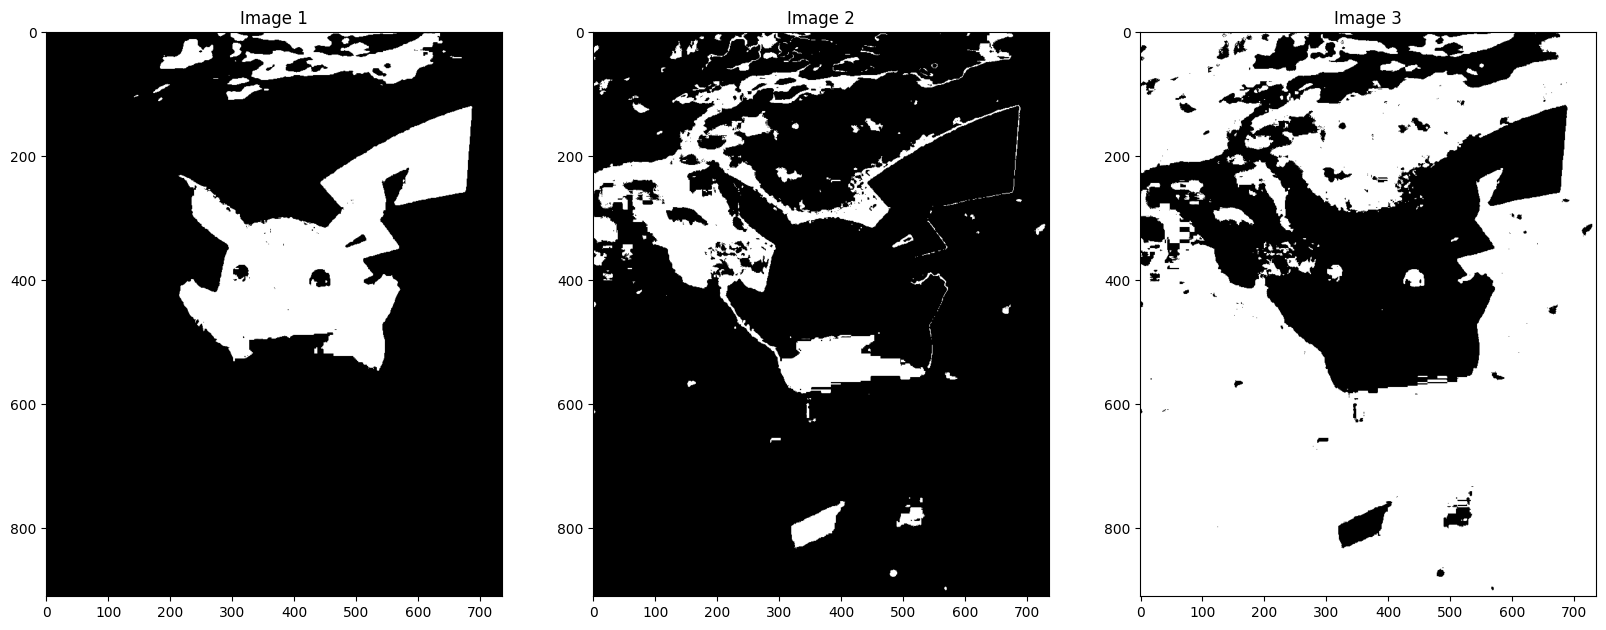

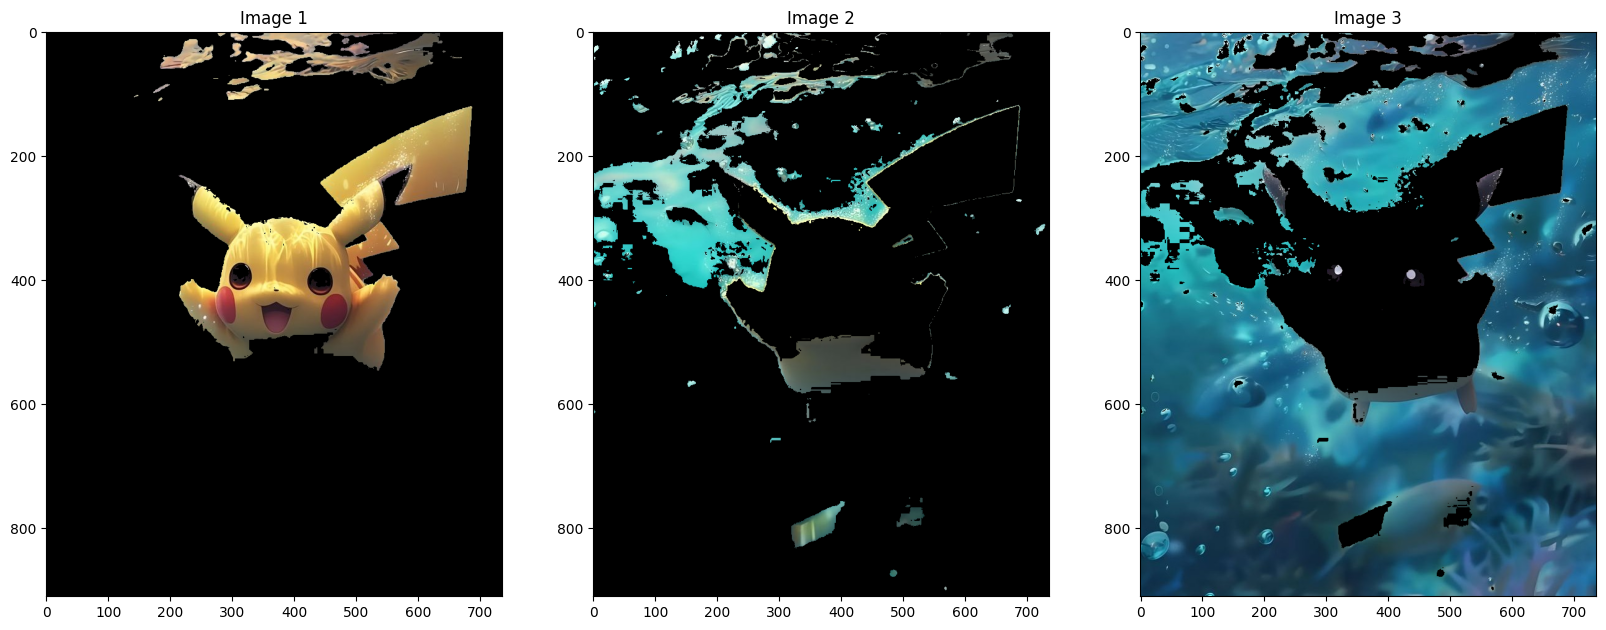

In [ ]:
image_maxR_mask = img3_GRAYSCALE < 0
image_maxG_mask = img3_GRAYSCALE < 0
image_maxB_mask = img3_GRAYSCALE < 0
image_maxGB_mask = img3_GRAYSCALE < 0

R = image_color_rgbmax[:,:,0]
G = image_color_rgbmax[:,:,1]
B = image_color_rgbmax[:,:,2]

image_maxR_mask[(G == 0) & (B == 0)] = 1
image_maxG_mask[(R == 0) & (B == 0)] = 1
image_maxB_mask[(G == 0) & (R == 0)] = 1

image_maxGB_mask[(B == 0)] = 1

image_maxR = SegmentColorImageByMask(img_3_rgb, image_maxR_mask)
image_maxG = SegmentColorImageByMask(img_3_rgb, image_maxG_mask)
image_maxB = SegmentColorImageByMask(img_3_rgb, image_maxB_mask)
image_maxGB = SegmentColorImageByMask(img_3_rgb, image_maxGB_mask)

ShowTwoImages(img_3_rgb, image_color_rgbmax)
ShowThreeImages(image_maxR_mask, image_maxG_mask, image_maxB_mask)
ShowThreeImages(image_maxR, image_maxG, image_maxB)


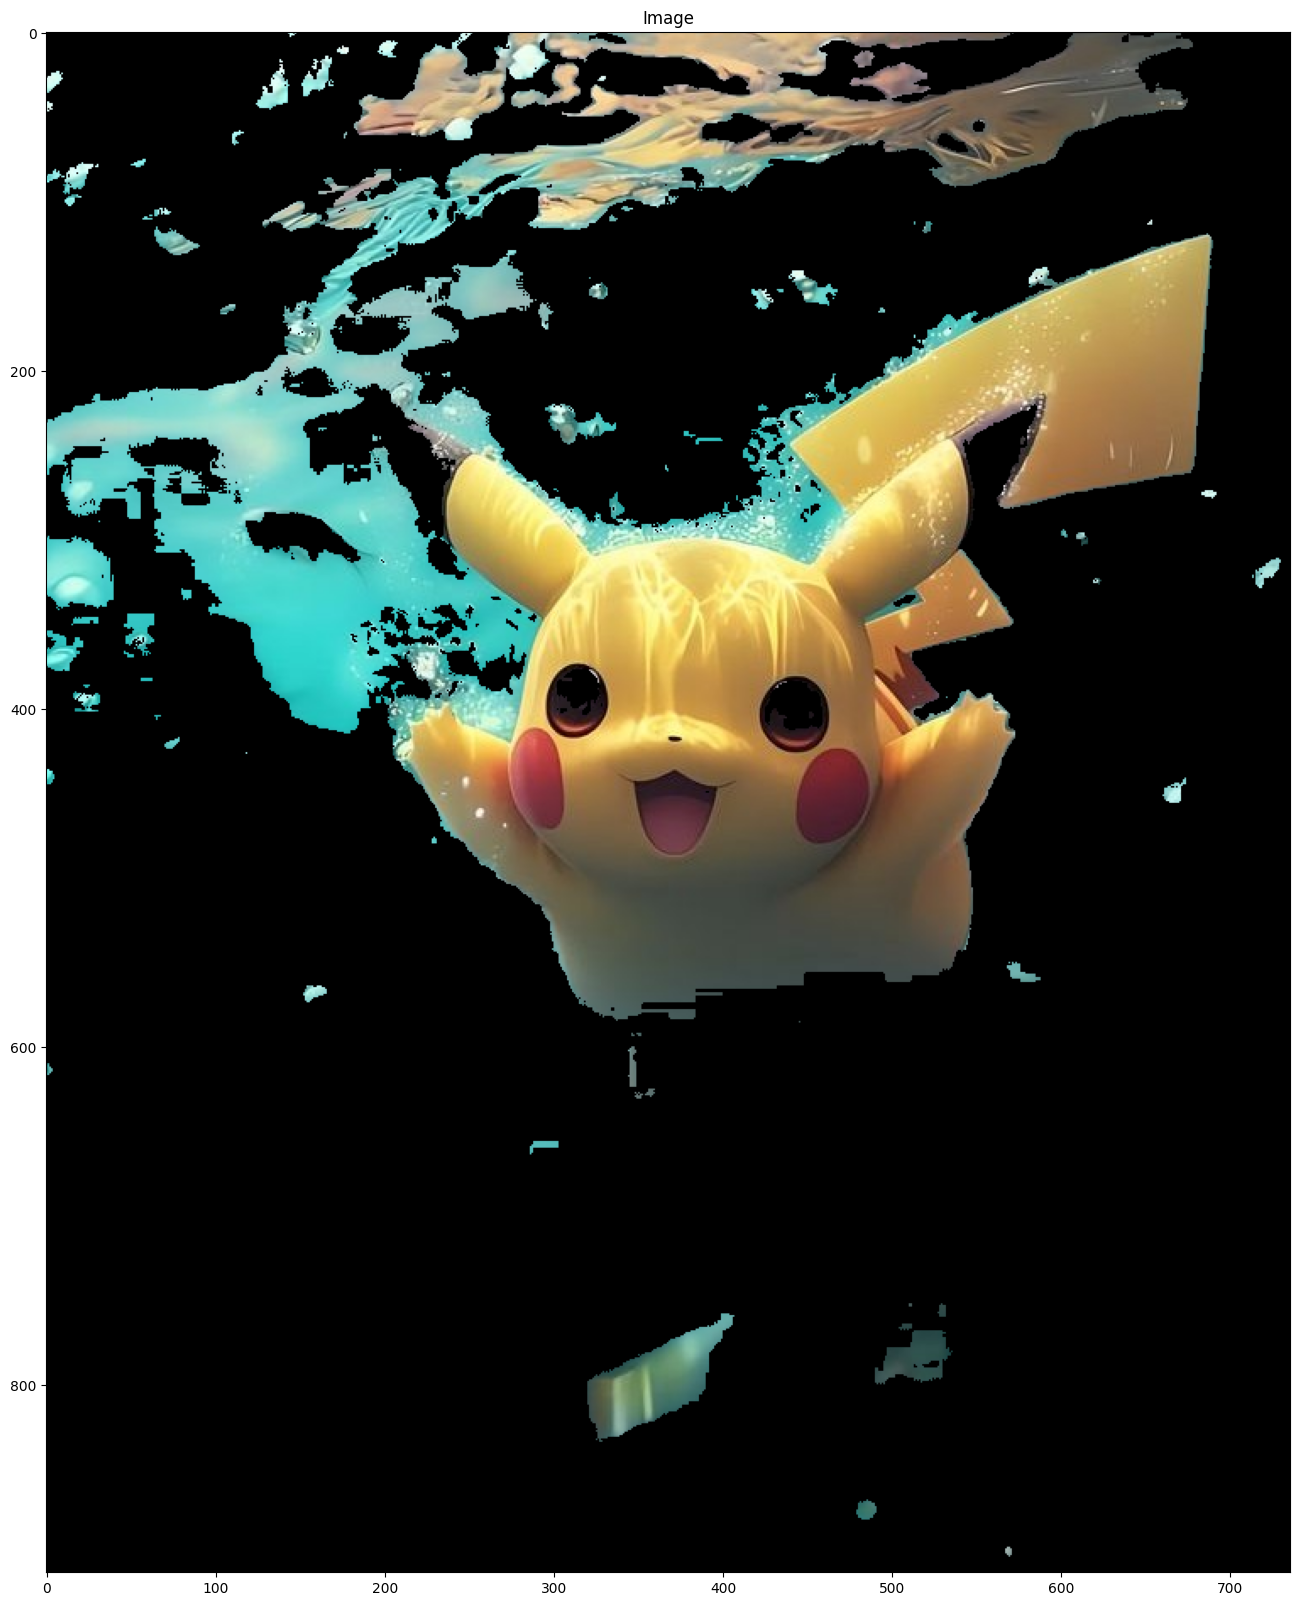

In [ ]:
ShowOneImage(image_maxGB)

# Homework

1. Choose an external image (from the internet or your computer) and complete all the above tasks.

2. . Understanding BINS in Histograms
    - Explain the concept of “bins” in the context of image histograms.
    - Describe how bins affect the construction and visualization of histograms

3. Justification for Using BINS
    - Discuss why histograms are divided into bins instead of showing individual pixel intensity values.
    - Explain how binning influences the accuracy and interpretability of histograms in image analysis.


4. Gamma and Logarithmic Correction
    - Apply Gamma Correction and Logarithmic Transformation to improve the image contrast.
    - Using cv2 instead of skimage in order to takes an image and a gamma value then returning the gamma-corrected result.
    - Write a Python function that takes an image and a gamma value and returns the gamma-corrected result without using cv2 or skimage built-in functions.
    - Combine Gamma + Logarithmic Correction sequentially. What happens if you apply Log → Gamma vs Gamma → Log?
    - Write a program to automatically find the optimal gamma value for each image based on:

      (a) The standard deviation of the gamma-corrected image.

      (b) The Shannon entropy of the gamma-corrected image.

      💡Hint: Iterate gamma values from 0.3 → 3.0, and choose the one that yields the highest contrast or entropy.

5. Histogram Equalization in HSV Color Space:
    - Apply histogram equalization independently on all three HSV channels (Hue, Saturation, Value) and display the result.
    - Apply histogram equalization only on the S (Saturation) and V (Value) channels to enhance image quality while preserving hue.
    - Plot and compare the histograms of the original image versus the equalized image, analyzing their visual differences.
    - Implement a function to perform histogram matching between two images:
      → one as the source and another as the reference.

      💡 Hint: You may use cv2.calcHist, cv2.LUT(), or skimage.exposure.match_histograms.

6. Create a binary mask using the following approaches (Please choose another external image and indicate whether the object can be separated or not.):
    - Based on a specific color channel (R, G, or B) condition.
    - Based on intensity thresholds in HSV channels (Hue, Saturation, Value).
    - Based on combined conditions (e.g., R > 200 AND G < 50).

    Apply the mask to the original image in order to extract the target object.

7. Report
    * Display the original image and all processed results (after each transformation).
    * Provide a brief commentary describing and comparing the visual differences observed between the methods.